In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
from sklearn.metrics import accuracy_score, classification_report

In [50]:
apple = pd.read_csv('../Yahoo_Finance/Apple/AAPL_historical_stock.csv')
apple

,Date,Open,High,Low,Close,Adj Close,Volume
0,1980-12-12,0.128348,0.128906,0.128348,0.128348,0.098207,469033600
1,1980-12-15,0.122210,0.122210,0.121652,0.121652,0.093083,175884800
2,1980-12-16,0.113281,0.113281,0.112723,0.112723,0.086251,105728000
3,1980-12-17,0.115513,0.116071,0.115513,0.115513,0.088386,86441600
4,1980-12-18,0.118862,0.119420,0.118862,0.118862,0.090949,73449600
...,...,...,...,...,...,...,...
11497,2026-07-29,339.730011,344.570007,337.350006,338.190002,338.190002,56090800
11498,2026-07-30,333.100006,334.750000,329.589996,333.429993,333.429993,74817800
11499,2026-07-31,304.809998,310.690002,300.000000,308.910004,308.910004,132489100
11500,2026-08-03,309.579987,311.799988,302.559998,303.420013,303.420013,74824300


In [51]:
# apple['Date'] = apple['Date'].str.extract(r'(\d{4}-\d{1,2})')
# apple

apple['observation_month'] = apple['Date'].str[:-3]
apple

,Date,Open,High,Low,Close,Adj Close,Volume,observation_month
0,1980-12-12,0.128348,0.128906,0.128348,0.128348,0.098207,469033600,1980-12
1,1980-12-15,0.122210,0.122210,0.121652,0.121652,0.093083,175884800,1980-12
2,1980-12-16,0.113281,0.113281,0.112723,0.112723,0.086251,105728000,1980-12
3,1980-12-17,0.115513,0.116071,0.115513,0.115513,0.088386,86441600,1980-12
4,1980-12-18,0.118862,0.119420,0.118862,0.118862,0.090949,73449600,1980-12
...,...,...,...,...,...,...,...,...
11497,2026-07-29,339.730011,344.570007,337.350006,338.190002,338.190002,56090800,2026-07
11498,2026-07-30,333.100006,334.750000,329.589996,333.429993,333.429993,74817800,2026-07
11499,2026-07-31,304.809998,310.690002,300.000000,308.910004,308.910004,132489100,2026-07
11500,2026-08-03,309.579987,311.799988,302.559998,303.420013,303.420013,74824300,2026-08


In [52]:
apple.dtypes

Date                     str
Open                 float64
High                 float64
Low                  float64
Close                float64
Adj Close            float64
Volume                 int64
observation_month        str
dtype: object

In [53]:
inflation = pd.read_csv('../FRED/inflation.csv')
inflation

,observation_date,CPIAUCSL
0,1947-01-01,21.480
1,1947-02-01,21.620
2,1947-03-01,22.000
3,1947-04-01,22.000
4,1947-05-01,21.950
...,...,...
949,2026-02-01,327.460
950,2026-03-01,330.293
951,2026-04-01,332.407
952,2026-05-01,333.979


In [54]:
inflation['observation_date'] = inflation['observation_date'].str[:-3]
inflation

,observation_date,CPIAUCSL
0,1947-01,21.480
1,1947-02,21.620
2,1947-03,22.000
3,1947-04,22.000
4,1947-05,21.950
...,...,...
949,2026-02,327.460
950,2026-03,330.293
951,2026-04,332.407
952,2026-05,333.979


In [55]:
inflation.isna().value_counts()

observation_date  CPIAUCSL
False             False       953
                  True          1
Name: count, dtype: int64

In [56]:
# inflation.dropna()

In [57]:
# apple['Date'] = pd.to_datetime(apple['Date']).dt.strftime('%Y-%m')
# inflation['Date'] = pd.to_datetime(inflation['Date']).dt.strftime('%Y-%m')


# inflation = inflation.rename(columns={'observation_date': 'Date'})
# merged = pd.merge(apple, inflation, on='Date', how='inner')


In [58]:
# inflation['observation_date'] = inflation['observation_date'].str[:-3]
# apple

In [59]:
# apple['Month'] = apple['Date'].str[5:-3]
# apple

In [60]:
df = pd.merge(apple, inflation, left_on='observation_month', right_on='observation_date')
df

,Date,Open,High,Low,Close,Adj Close,Volume,observation_month,observation_date,CPIAUCSL
0,1980-12-12,0.128348,0.128906,0.128348,0.128348,0.098207,469033600,1980-12,1980-12,86.400
1,1980-12-15,0.122210,0.122210,0.121652,0.121652,0.093083,175884800,1980-12,1980-12,86.400
2,1980-12-16,0.113281,0.113281,0.112723,0.112723,0.086251,105728000,1980-12,1980-12,86.400
3,1980-12-17,0.115513,0.116071,0.115513,0.115513,0.088386,86441600,1980-12,1980-12,86.400
4,1980-12-18,0.118862,0.119420,0.118862,0.118862,0.090949,73449600,1980-12,1980-12,86.400
...,...,...,...,...,...,...,...,...,...,...
11473,2026-06-24,295.359985,299.700012,292.940002,293.079987,293.079987,53081900,2026-06,2026-06,332.568
11474,2026-06-25,287.399994,288.799988,273.750000,275.149994,275.149994,107013700,2026-06,2026-06,332.568
11475,2026-06-26,275.000000,285.950012,274.209991,283.779999,283.779999,261775500,2026-06,2026-06,332.568
11476,2026-06-29,286.730011,288.369995,279.850006,281.739990,281.739990,66427000,2026-06,2026-06,332.568


In [61]:
df = df[df['CPIAUCSL'].notna()]

<Axes: xlabel='Close', ylabel='CPIAUCSL'>

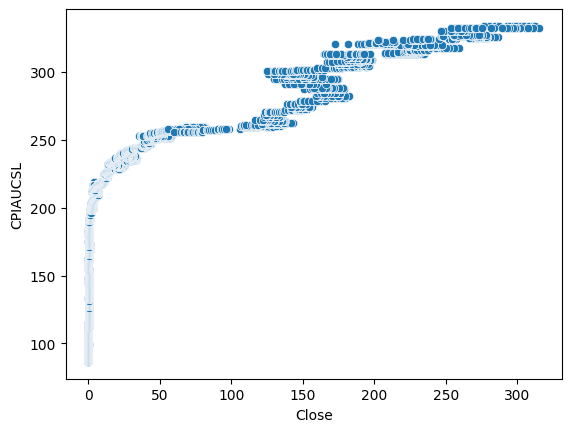

In [62]:
sns.scatterplot(data=df, x= 'Close', y='CPIAUCSL')

In [63]:
df_1 = df[['Close', 'CPIAUCSL']]
df_1

,Close,CPIAUCSL
0,0.128348,86.400
1,0.121652,86.400
2,0.112723,86.400
3,0.115513,86.400
4,0.118862,86.400
...,...,...
11473,293.079987,332.568
11474,275.149994,332.568
11475,283.779999,332.568
11476,281.739990,332.568


In [64]:
df_1.corr()

,Close,CPIAUCSL
Close,1.000000,0.772256
CPIAUCSL,0.772256,1.000000


In [65]:
df['CPIAUCSL'].isna().value_counts()

CPIAUCSL
False    11455
Name: count, dtype: int64

In [66]:
# seprating training and testing
X_train, X_test, y_train, y_test = train_test_split(df[['Close']], df['CPIAUCSL'], test_size=0.2, random_state=42)
y_train.shape

(9164,)

In [67]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

ValueError: Unknown label type: continuous. Maybe you are trying to fit a classifier, which expects discrete classes on a regression target with continuous values.